In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. Load dữ liệu
# Đảm bảo bạn đã có file ECG5000_full.csv trong thư mục data/raw/
df = pd.read_csv('../data/raw/ECG5000_full.csv', header=None)

print(f"Kích thước bộ dữ liệu: {df.shape}")
df.head()

Kích thước bộ dữ liệu: (5000, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,1.0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,1.0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,1.0,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,1.0,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,1.0,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16220\4281593436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


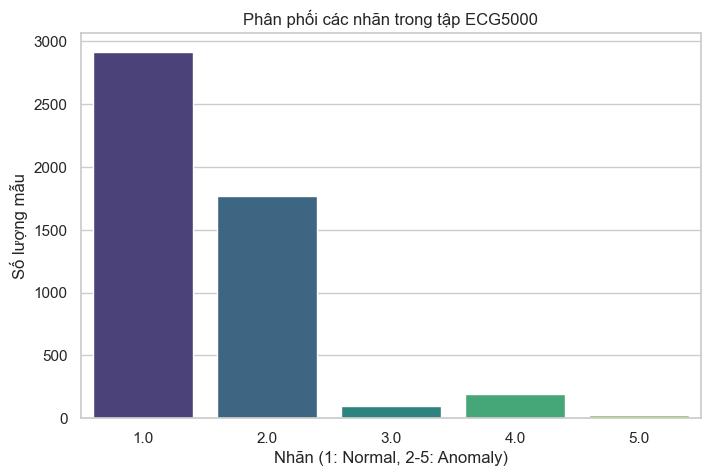

Số lượng chi tiết:
0
1.0    2919
2.0    1767
3.0      96
4.0     194
5.0      24
Name: count, dtype: int64


In [3]:
# Cột 0 là nhãn (Label)
# 1: Normal (Bình thường)
# 2, 3, 4, 5: Các loại bất thường khác nhau (Anomaly)

# Đếm số lượng mỗi nhãn
label_counts = df[0].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Phân phối các nhãn trong tập ECG5000")
plt.xlabel("Nhãn (1: Normal, 2-5: Anomaly)")
plt.ylabel("Số lượng mẫu")
plt.show()

print("Số lượng chi tiết:")
print(label_counts)

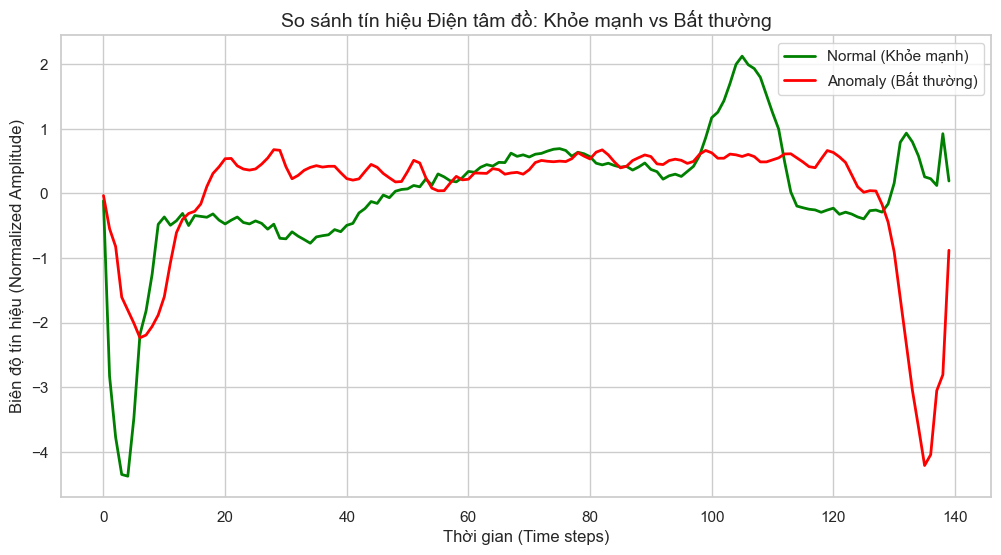

In [4]:
# Tách dữ liệu thành 2 nhóm: Bình thường (nhãn 1) và Bất thường (nhãn khác 1)
# Bỏ đi cột nhãn (cột 0) để chỉ giữ lại 140 điểm thời gian của tín hiệu
normal_beats = df[df[0] == 1].drop(columns=[0])
abnormal_beats = df[df[0] != 1].drop(columns=[0])

# Vẽ biểu đồ so sánh trực quan
plt.figure(figsize=(12, 6))

# Lấy mẫu đầu tiên của mỗi nhóm để vẽ đường (Line plot)
plt.plot(normal_beats.iloc[0].values, label="Normal (Khỏe mạnh)", color='green', linewidth=2)
plt.plot(abnormal_beats.iloc[0].values, label="Anomaly (Bất thường)", color='red', linewidth=2)

plt.title("So sánh tín hiệu Điện tâm đồ: Khỏe mạnh vs Bất thường", fontsize=14)
plt.xlabel("Thời gian (Time steps)", fontsize=12)
plt.ylabel("Biên độ tín hiệu (Normalized Amplitude)", fontsize=12)
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Tách riêng dữ liệu Bình thường (Normal = nhãn 1) và Bất thường (Anomaly = nhãn khác 1)
# Bỏ cột nhãn đi, chỉ lấy giá trị (values)
normal_data = df[df[0] == 1].drop(columns=[0]).values
anomaly_data = df[df[0] != 1].drop(columns=[0]).values

# 2. Chia tập Train/Test cho dữ liệu Normal (Train 80%, Test 20%)
train_data, test_normal = train_test_split(normal_data, test_size=0.2, random_state=42)

# 3. Tạo tập Test cuối cùng = 20% Normal còn lại + Toàn bộ Anomaly
test_data = np.vstack((test_normal, anomaly_data))

# Tạo nhãn cho tập Test để tính độ chính xác sau này (Normal = 0, Anomaly = 1)
test_labels = np.concatenate((np.zeros(len(test_normal)), np.ones(len(anomaly_data))))

# 4. Chuẩn hóa dữ liệu (Đưa các giá trị về khoảng [0, 1] để Deep Learning học tốt hơn)
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data) # Chỉ transform, không fit trên tập test

print(f"✅ Kích thước tập Train (chỉ có Normal): {train_data_scaled.shape}")
print(f"✅ Kích thước tập Test (Normal + Anomaly): {test_data_scaled.shape}")

✅ Kích thước tập Train (chỉ có Normal): (2335, 140)
✅ Kích thước tập Test (Normal + Anomaly): (2665, 140)


In [6]:
import numpy as np
import os

os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/train_data.npy', train_data_scaled)
np.save('../data/processed/test_data.npy', test_data_scaled)
np.save('../data/processed/test_labels.npy', test_labels)

# Lưu cả scaler để dùng lại khi inference/demo
import joblib
joblib.dump(scaler, '../data/processed/scaler.pkl')

print("✅ Đã lưu toàn bộ dữ liệu đã xử lý vào data/processed/")

✅ Đã lưu toàn bộ dữ liệu đã xử lý vào data/processed/
